In [2]:
import os
import copy
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Tohum ve Cihaz Ayarı
torch.manual_seed(42)
np.random.seed(42)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Klasör Yollarını Otomatik Bul
train_dir, test_dir = None, None
for root, dirs, files in os.walk('/kaggle/input'):
    if 'train' in dirs and train_dir is None:
        train_dir = os.path.join(root, 'train')
    if 'test' in dirs and test_dir is None:
        test_dir = os.path.join(root, 'test')

print(" Cihaz:", device)
print(" Train Yolu:", train_dir)
print(" Test Yolu :", test_dir)

 Cihaz: cuda:0
 Train Yolu: /kaggle/input/datasets/melihrek/squat-posture-classification-final/train
 Test Yolu : /kaggle/input/datasets/melihrek/squat-posture-classification-final/test


In [3]:
# =========================================================
# 1. DATA AUGMENTATION / PREPROCESSING
# =========================================================

import os
import re

# TRAIN için güçlü augmentation
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=20),
    transforms.ColorJitter(
        brightness=0.3,
        contrast=0.3,
        saturation=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
    transforms.RandomErasing(
        p=0.25,
        scale=(0.02, 0.2),
        value="random"
    )
])

# VALIDATION ve TEST için augmentation YOK
val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


# =========================================================
# 2. AYNI TRAIN KLASÖRÜNÜ İKİ FARKLI TRANSFORM İLE YÜKLE
# =========================================================

# Train tarafında augmentation uygulanacak
full_train_aug = datasets.ImageFolder(
    train_dir,
    transform=train_transforms
)

# Validation tarafında augmentation uygulanmayacak
full_train_eval = datasets.ImageFolder(
    train_dir,
    transform=val_test_transforms
)

# Orijinal test klasörünün TAMAMI final test olarak kalacak
test_dataset = datasets.ImageFolder(
    test_dir,
    transform=val_test_transforms
)

class_names = full_train_aug.classes

print("Sınıflar:", class_names)


# =========================================================
# 3. MANUEL BELİRLEDİĞİMİZ BAĞIMSIZ VALIDATION GRUPLARI
# =========================================================

# Belirlenen görüntü gruplarını validation kümesine ayır

validation_ranges = {

    # GOOD
    "Good": [
        (1, 15),
        (16, 30),
        (31, 40),
        (293, 508),
        (985, 1001)
    ],

    # BAD HEEL
    "Bad heel": [
        (1, 15),
        (16, 32),
        (33, 42),
        (751, 852)
    ],

    # BAD BACK
    "Bad back": [
        (1, 25),
        (26, 40),
        (41, 50),
        (170, 265)
    ]
}


# =========================================================
# 4. DOSYA ADINDAN NUMARAYI BULAN FONKSİYON
# Örnek: "Good (509).jpg" -> 509
# =========================================================

def get_image_number(filepath):
    filename = os.path.basename(filepath)

    numbers = re.findall(r"\d+", filename)

    if len(numbers) == 0:
        return None

    return int(numbers[-1])


# =========================================================
# 5. TRAIN VE VALIDATION INDEXLERİNİ AYIR
# =========================================================

train_indices = []
val_indices = []

# Her görüntüyü tek tek kontrol ediyoruz
for index, (filepath, class_index) in enumerate(full_train_aug.samples):

    class_name = class_names[class_index]

    image_number = get_image_number(filepath)

    is_validation = False

    # Bu sınıf için belirlediğimiz validation aralıklarını kontrol et
    if class_name in validation_ranges and image_number is not None:

        for start_num, end_num in validation_ranges[class_name]:

            if start_num <= image_number <= end_num:
                is_validation = True
                break

    if is_validation:
        val_indices.append(index)
    else:
        train_indices.append(index)


# =========================================================
# 6. TRAIN / VALIDATION DATASET
# =========================================================

# Train indexleri augmentation'lı dataset'ten alınır
train_dataset = torch.utils.data.Subset(
    full_train_aug,
    train_indices
)

# Validation indexleri augmentation'sız dataset'ten alınır
val_dataset = torch.utils.data.Subset(
    full_train_eval,
    val_indices
)


# =========================================================
# 7. DATALOADERS
# =========================================================

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0
)


# =========================================================
# 8. KONTROLLER
# =========================================================

print("\n" + "=" * 55)
print("MANUEL VIDEO/ÇEKİM BAZLI SPLIT")
print("=" * 55)

print(f"Train      : {len(train_dataset)}")
print(f"Validation : {len(val_dataset)}")
print(f"Test       : {len(test_dataset)}")

print("\nValidation'a seçilen gruplar:")

for class_name, ranges in validation_ranges.items():
    print(f"{class_name}: {ranges}")


# =========================================================
# 9. TRAIN - VALIDATION ÇAKIŞMA KONTROLÜ
# =========================================================

train_set_indices = set(train_indices)
val_set_indices = set(val_indices)

overlap = train_set_indices.intersection(val_set_indices)

if len(overlap) == 0:
    print("\n Train ve Validation arasında index çakışması YOK.")
else:
    print("\n DİKKAT! Train ve Validation arasında çakışma var!")


# =========================================================
# 10. VALIDATION SINIF DAĞILIMI
# =========================================================

val_class_counts = {
    class_name: 0
    for class_name in class_names
}

for index in val_indices:
    _, class_index = full_train_aug.samples[index]
    class_name = class_names[class_index]

    val_class_counts[class_name] += 1

print("\nValidation sınıf dağılımı:")

for class_name, count in val_class_counts.items():
    print(f"{class_name}: {count}")

Sınıflar: ['Bad back', 'Bad heel', 'Good']

MANUEL VIDEO/ÇEKİM BAZLI SPLIT
Train      : 2274
Validation : 563
Test       : 969

Validation'a seçilen gruplar:
Good: [(1, 15), (16, 30), (31, 40), (293, 508), (985, 1001)]
Bad heel: [(1, 15), (16, 32), (33, 42), (751, 852)]
Bad back: [(1, 25), (26, 40), (41, 50), (170, 265)]

 Train ve Validation arasında index çakışması YOK.

Validation sınıf dağılımı:
Bad back: 146
Bad heel: 144
Good: 273


In [7]:
# ============================================================
# CUSTOM CNN - MANUEL VALIDATION SETİNİ KULLAN
# ============================================================

import copy
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

print("🚀 Custom CNN manuel split ile hazırlanıyor...")

# ============================================================
# ÖNCEKİ HÜCREDE HAZIRLANAN MANUEL SETLER
# ============================================================

train_data = train_dataset
val_data = val_dataset

print("Train      :", len(train_data))
print("Validation :", len(val_data))
print("Test       :", len(test_dataset))

# Burada beklenen:
# Train      : 2274
# Validation : 563
# Test       : 969


# ============================================================
# CUSTOM CNN
# ============================================================

class RobustCustomCNN(nn.Module):

    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                256 * 14 * 14,
                512
            ),

            nn.ReLU(),

            nn.Dropout(p=0.60),

            nn.Linear(
                512,
                num_classes
            )
        )

    def forward(self, x):

        x = self.features(x)

        return self.classifier(x)


model_custom = RobustCustomCNN(
    num_classes=len(class_names)
).to(device)


# ============================================================
# CLASS WEIGHTS
# SADECE MANUEL TRAIN INDEXLERİNDEN
# ============================================================

train_labels = [
    full_train_aug.samples[i][1]
    for i in train_indices
]

class_counts = np.bincount(
    train_labels,
    minlength=len(class_names)
)

weights = (
    len(train_labels)
    /
    (
        len(class_names)
        *
        class_counts.astype(np.float32)
    )
)

print("\nTrain class distribution:")

for i, cls in enumerate(class_names):
    print(cls, ":", class_counts[i])


criterion = nn.CrossEntropyLoss(
    weight=torch.FloatTensor(weights).to(device),
    label_smoothing=0.1
)


optimizer = optim.AdamW(
    model_custom.parameters(),
    lr=1e-4,
    weight_decay=1e-2
)


scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=30
)


print("\n✅ CNN hazır.")

🚀 Custom CNN manuel split ile hazırlanıyor...
Train      : 2274
Validation : 563
Test       : 969

Train class distribution:
Bad back : 838
Bad heel : 708
Good : 728

✅ CNN hazır.


🚀 Custom CNN eğitimi başlıyor...
Maximum Epoch : 30
Early Stopping Patience : 5

Epoch 01/30 | Train Loss: 1.4272 - Acc: %45.25 | Val Loss: 1.3598 - Acc: %24.16
   ⭐ New best model! Val Loss: 1.3598
Epoch 02/30 | Train Loss: 0.8586 - Acc: %63.72 | Val Loss: 2.0196 - Acc: %10.66
   No improvement: 1/5
Epoch 03/30 | Train Loss: 0.7781 - Acc: %69.96 | Val Loss: 1.9690 - Acc: %14.21
   No improvement: 2/5
Epoch 04/30 | Train Loss: 0.7322 - Acc: %75.24 | Val Loss: 2.2151 - Acc: %27.71
   No improvement: 3/5
Epoch 05/30 | Train Loss: 0.6904 - Acc: %77.09 | Val Loss: 2.0317 - Acc: %14.56
   No improvement: 4/5
Epoch 06/30 | Train Loss: 0.6519 - Acc: %79.64 | Val Loss: 1.9861 - Acc: %27.00
   No improvement: 5/5

🛑 EARLY STOPPING at Epoch 6
⭐ Best Epoch: 1
⭐ Best Validation Loss: 1.3598

✅ Eğitim tamamlandı.
✅ Best Epoch: 1
✅ Best Validation Loss: 1.3598

🚀 Final Test başlıyor...

🎯 CUSTOM CNN FINAL TEST ACCURACY: %35.50

CLASSIFICATION REPORT:

              precision    recall  f1-score   su

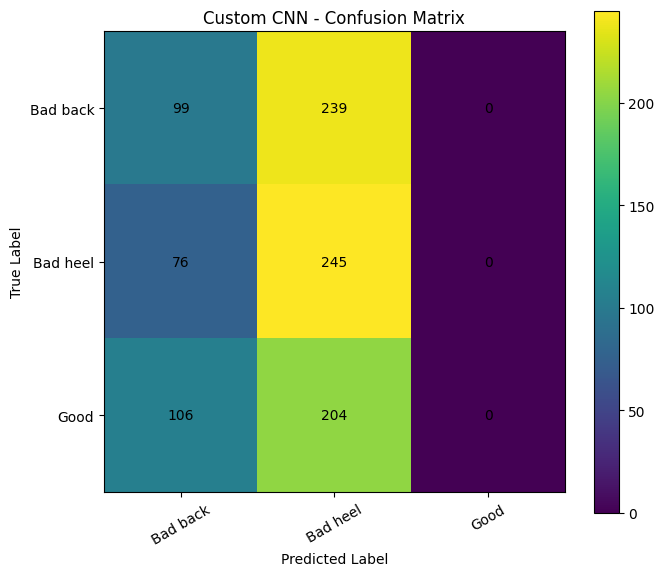

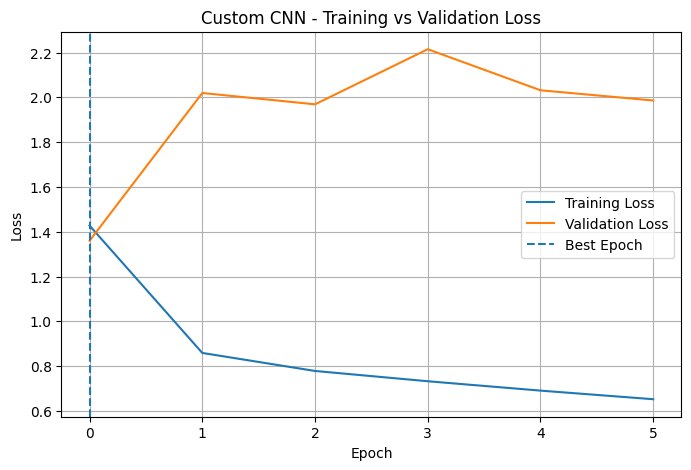

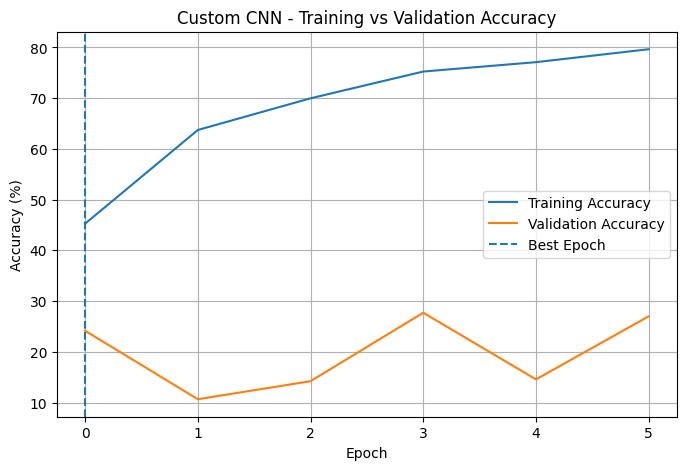

In [8]:
# ============================================================
# CUSTOM CNN - FINAL TRAINING
# 30 Epoch + Early Stopping + Best Model
# ============================================================

import copy
import torch
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# ============================================================
# AYARLAR
# ============================================================

NUM_EPOCHS = 30
PATIENCE = 5

best_val_loss = float("inf")
epochs_without_improvement = 0
best_epoch = 0

best_weights = copy.deepcopy(
    model_custom.state_dict()
)

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

print("🚀 Custom CNN eğitimi başlıyor...")
print(f"Maximum Epoch : {NUM_EPOCHS}")
print(f"Early Stopping Patience : {PATIENCE}")
print()


# ============================================================
# TRAINING LOOP
# ============================================================

for epoch in range(NUM_EPOCHS):

    # ========================================================
    # 1. TRAINING
    # ========================================================

    model_custom.train()

    running_loss = 0.0
    running_corrects = 0

    for inputs, labels in train_loader:

        inputs = inputs.to(device)
        labels = labels.to(device)

        # Gradientleri sıfırla
        optimizer.zero_grad()

        # Forward
        outputs = model_custom(inputs)

        # Loss
        loss = criterion(
            outputs,
            labels
        )

        # Prediction
        _, preds = torch.max(
            outputs,
            1
        )

        # Backpropagation
        loss.backward()

        # Weight update
        optimizer.step()

        running_loss += (
            loss.item()
            * inputs.size(0)
        )

        running_corrects += torch.sum(
            preds == labels
        )


    # ========================================================
    # TRAIN METRICS
    # ========================================================

    train_loss = (
        running_loss
        / len(train_dataset)
    )

    train_acc = (
        running_corrects.double()
        / len(train_dataset)
    ).item() * 100


    # ========================================================
    # 2. VALIDATION
    # ========================================================

    model_custom.eval()

    val_running_loss = 0.0
    val_corrects = 0

    with torch.no_grad():

        for inputs, labels in val_loader:

            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model_custom(inputs)

            loss = criterion(
                outputs,
                labels
            )

            _, preds = torch.max(
                outputs,
                1
            )

            val_running_loss += (
                loss.item()
                * inputs.size(0)
            )

            val_corrects += torch.sum(
                preds == labels
            )


    # ========================================================
    # VALIDATION METRICS
    # ========================================================

    val_loss = (
        val_running_loss
        / len(val_dataset)
    )

    val_acc = (
        val_corrects.double()
        / len(val_dataset)
    ).item() * 100


    # ========================================================
    # HISTORY
    # ========================================================

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)

    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)


    # ========================================================
    # SONUÇLARI YAZDIR
    # ========================================================

    print(
        f"Epoch {epoch+1:02d}/{NUM_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} "
        f"- Acc: %{train_acc:.2f} | "
        f"Val Loss: {val_loss:.4f} "
        f"- Acc: %{val_acc:.2f}"
    )


    # ========================================================
    # 3. EARLY STOPPING + BEST MODEL
    # ========================================================

    if val_loss < best_val_loss:

        best_val_loss = val_loss
        best_epoch = epoch + 1

        best_weights = copy.deepcopy(
            model_custom.state_dict()
        )

        epochs_without_improvement = 0

        print(
            f"   ⭐ New best model! "
            f"Val Loss: {best_val_loss:.4f}"
        )

    else:

        epochs_without_improvement += 1

        print(
            f"   No improvement: "
            f"{epochs_without_improvement}/{PATIENCE}"
        )


    # ========================================================
    # LEARNING RATE SCHEDULER
    # ========================================================

    scheduler.step()


    # ========================================================
    # EARLY STOPPING KONTROLÜ
    # ========================================================

    if epochs_without_improvement >= PATIENCE:

        print("\n" + "=" * 60)

        print(
            f"🛑 EARLY STOPPING at Epoch {epoch+1}"
        )

        print(
            f"⭐ Best Epoch: {best_epoch}"
        )

        print(
            f"⭐ Best Validation Loss: "
            f"{best_val_loss:.4f}"
        )

        print("=" * 60)

        break


# ============================================================
# EN İYİ MODELİ GERİ YÜKLE
# ============================================================

model_custom.load_state_dict(
    best_weights
)

print("\n✅ Eğitim tamamlandı.")

print(
    f"✅ Best Epoch: {best_epoch}"
)

print(
    f"✅ Best Validation Loss: "
    f"{best_val_loss:.4f}"
)


# ============================================================
# 4. FINAL TEST
# ============================================================

print("\n🚀 Final Test başlıyor...")

model_custom.eval()

test_preds = []
test_labels = []

with torch.no_grad():

    for inputs, labels in test_loader:

        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model_custom(inputs)

        _, preds = torch.max(
            outputs,
            1
        )

        test_preds.extend(
            preds.cpu().numpy()
        )

        test_labels.extend(
            labels.cpu().numpy()
        )


# ============================================================
# TEST ACCURACY
# ============================================================

test_accuracy = accuracy_score(
    test_labels,
    test_preds
) * 100

print("\n" + "=" * 60)

print(
    f"🎯 CUSTOM CNN FINAL TEST ACCURACY: "
    f"%{test_accuracy:.2f}"
)

print("=" * 60)


# ============================================================
# CLASSIFICATION REPORT
# ============================================================

print("\nCLASSIFICATION REPORT:\n")

print(
    classification_report(
        test_labels,
        test_preds,
        target_names=class_names,
        zero_division=0
    )
)


# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    test_labels,
    test_preds
)

plt.figure(
    figsize=(7, 6)
)

plt.imshow(cm)

plt.title(
    "Custom CNN - Confusion Matrix"
)

plt.xlabel(
    "Predicted Label"
)

plt.ylabel(
    "True Label"
)

plt.xticks(
    range(len(class_names)),
    class_names,
    rotation=30
)

plt.yticks(
    range(len(class_names)),
    class_names
)

for i in range(len(class_names)):

    for j in range(len(class_names)):

        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.tight_layout()
plt.show()


# ============================================================
# 5. LOSS GRAPH
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    history["train_loss"],
    label="Training Loss"
)

plt.plot(
    history["val_loss"],
    label="Validation Loss"
)

plt.axvline(
    best_epoch - 1,
    linestyle="--",
    label="Best Epoch"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Custom CNN - Training vs Validation Loss"
)

plt.legend()
plt.grid(True)
plt.show()


# ============================================================
# 6. ACCURACY GRAPH
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    history["train_acc"],
    label="Training Accuracy"
)

plt.plot(
    history["val_acc"],
    label="Validation Accuracy"
)

plt.axvline(
    best_epoch - 1,
    linestyle="--",
    label="Best Epoch"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")

plt.title(
    "Custom CNN - Training vs Validation Accuracy"
)

plt.legend()
plt.grid(True)
plt.show()

In [9]:
# ============================================================
# MOBILENETV3 LARGE - MANUEL VALIDATION SPLIT
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models

print("🚀 MobileNetV3 hazırlanıyor...")

# ============================================================
# SPLIT KONTROLÜ
# ============================================================

print("\n" + "=" * 55)
print("MOBILENETV3 - MANUEL SPLIT KONTROLÜ")
print("=" * 55)

print("Train      :", len(train_dataset))
print("Validation :", len(val_dataset))
print("Test       :", len(test_dataset))

# Burada MUTLAKA:
# Train      : 2274
# Validation : 563
# Test       : 969
# görmelisin.


# ============================================================
# PRETRAINED MOBILENETV3 LARGE
# ============================================================

weights = models.MobileNet_V3_Large_Weights.DEFAULT

model_mobilenet = models.mobilenet_v3_large(
    weights=weights
)


# ============================================================
# FEATURE EXTRACTOR'I İLK AŞAMADA DONDUR
# ============================================================

for param in model_mobilenet.features.parameters():
    param.requires_grad = False


# ============================================================
# CLASSIFIER'I 3 SINIFA UYARLA
# ============================================================

in_features = model_mobilenet.classifier[0].in_features

model_mobilenet.classifier = nn.Sequential(

    nn.Linear(
        in_features,
        256
    ),

    nn.Hardswish(),

    nn.Dropout(
        p=0.40
    ),

    nn.Linear(
        256,
        len(class_names)
    )
)


model_mobilenet = model_mobilenet.to(device)


# ============================================================
# LOSS
# ============================================================

criterion_mobilenet = nn.CrossEntropyLoss(
    label_smoothing=0.05
)


# ============================================================
# OPTIMIZER
# Sadece classifier öğreniyor
# ============================================================

optimizer_mobilenet = optim.AdamW(

    model_mobilenet.classifier.parameters(),

    lr=1e-3,

    weight_decay=1e-3
)


# ============================================================
# SCHEDULER
# ============================================================

scheduler_mobilenet = optim.lr_scheduler.CosineAnnealingLR(

    optimizer_mobilenet,

    T_max=30
)


print("\n✅ MobileNetV3 hazır.")

print("Pretrained       : ImageNet")
print("Feature extractor: Frozen")
print("Dropout          : 0.40")
print("Learning Rate    : 0.001")
print("Max Epoch        : 30")
print("Classes          :", class_names)

🚀 MobileNetV3 hazırlanıyor...

MOBILENETV3 - MANUEL SPLIT KONTROLÜ
Train      : 2274
Validation : 563
Test       : 969
Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-5c1a4163.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-5c1a4163.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 185MB/s]



✅ MobileNetV3 hazır.
Pretrained       : ImageNet
Feature extractor: Frozen
Dropout          : 0.40
Learning Rate    : 0.001
Max Epoch        : 30
Classes          : ['Bad back', 'Bad heel', 'Good']


🚀 MobileNetV3 eğitimi başlıyor...
Maximum Epoch : 30
Early Stopping Patience : 5

Epoch 01/30 | Train Loss: 0.6503 - Acc: %76.39 | Val Loss: 2.4690 - Acc: %20.07
   ⭐ New best model! Val Loss: 2.4690
Epoch 02/30 | Train Loss: 0.4109 - Acc: %89.67 | Val Loss: 2.1562 - Acc: %28.77
   ⭐ New best model! Val Loss: 2.1562
Epoch 03/30 | Train Loss: 0.3469 - Acc: %93.40 | Val Loss: 2.6628 - Acc: %22.91
   No improvement: 1/5
Epoch 04/30 | Train Loss: 0.3216 - Acc: %94.20 | Val Loss: 2.4654 - Acc: %20.25
   No improvement: 2/5
Epoch 05/30 | Train Loss: 0.3346 - Acc: %93.40 | Val Loss: 2.1626 - Acc: %17.76
   No improvement: 3/5
Epoch 06/30 | Train Loss: 0.2973 - Acc: %95.29 | Val Loss: 1.8498 - Acc: %18.12
   ⭐ New best model! Val Loss: 1.8498
Epoch 07/30 | Train Loss: 0.3120 - Acc: %94.90 | Val Loss: 1.9802 - Acc: %16.34
   No improvement: 1/5
Epoch 08/30 | Train Loss: 0.3114 - Acc: %94.50 | Val Loss: 2.1245 - Acc: %18.83
   No improvement: 2/5
Epoch 09/30 | Train Loss: 0.2930 - Acc: %95.91 | 

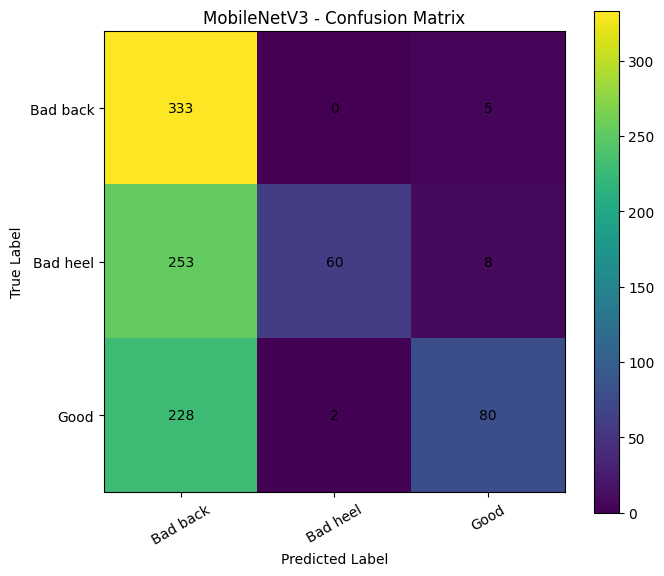

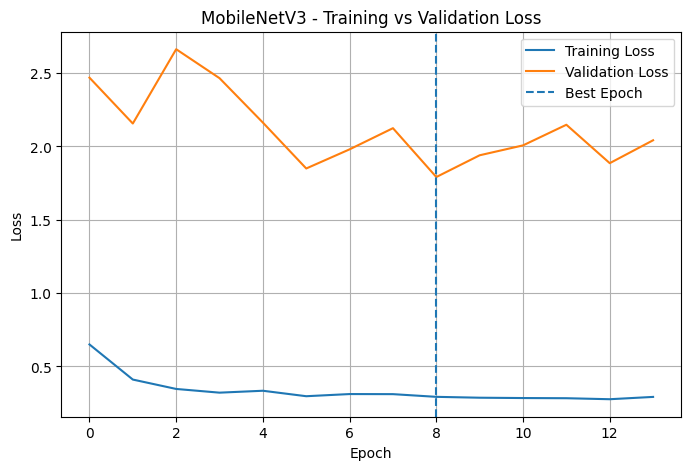

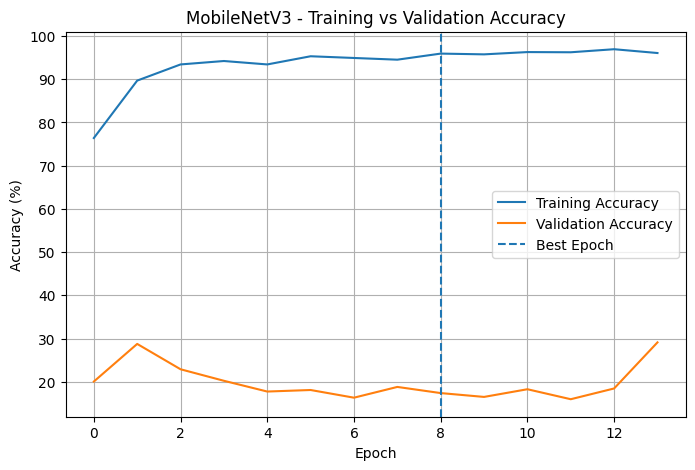

In [10]:
# ============================================================
# MOBILENETV3 TRAINING
# 30 Epoch + Early Stopping + Best Model
# ============================================================

import copy
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)


# ============================================================
# SETTINGS
# ============================================================

NUM_EPOCHS = 30
PATIENCE = 5

best_val_loss = float("inf")

epochs_without_improvement = 0

best_epoch = 0

best_weights = copy.deepcopy(
    model_mobilenet.state_dict()
)


history_mobilenet = {

    "train_loss": [],
    "train_acc": [],

    "val_loss": [],
    "val_acc": []
}


print("🚀 MobileNetV3 eğitimi başlıyor...")

print(
    f"Maximum Epoch : {NUM_EPOCHS}"
)

print(
    f"Early Stopping Patience : {PATIENCE}"
)

print()


# ============================================================
# TRAINING LOOP
# ============================================================

for epoch in range(NUM_EPOCHS):


    # ========================================================
    # TRAIN
    # ========================================================

    model_mobilenet.train()

    running_loss = 0.0

    running_corrects = 0


    for inputs, labels in train_loader:

        inputs = inputs.to(device)

        labels = labels.to(device)


        optimizer_mobilenet.zero_grad()


        outputs = model_mobilenet(
            inputs
        )


        loss = criterion_mobilenet(
            outputs,
            labels
        )


        _, preds = torch.max(
            outputs,
            1
        )


        loss.backward()


        optimizer_mobilenet.step()


        running_loss += (
            loss.item()
            *
            inputs.size(0)
        )


        running_corrects += torch.sum(
            preds == labels
        )


    # ========================================================
    # TRAIN METRICS
    # ========================================================

    train_loss = (
        running_loss
        /
        len(train_dataset)
    )


    train_acc = (
        running_corrects.double()
        /
        len(train_dataset)
    ).item() * 100



    # ========================================================
    # VALIDATION
    # ========================================================

    model_mobilenet.eval()


    val_running_loss = 0.0

    val_corrects = 0


    with torch.no_grad():


        for inputs, labels in val_loader:


            inputs = inputs.to(device)

            labels = labels.to(device)


            outputs = model_mobilenet(
                inputs
            )


            loss = criterion_mobilenet(
                outputs,
                labels
            )


            _, preds = torch.max(
                outputs,
                1
            )


            val_running_loss += (
                loss.item()
                *
                inputs.size(0)
            )


            val_corrects += torch.sum(
                preds == labels
            )


    # ========================================================
    # VALIDATION METRICS
    # ========================================================

    val_loss = (
        val_running_loss
        /
        len(val_dataset)
    )


    val_acc = (
        val_corrects.double()
        /
        len(val_dataset)
    ).item() * 100



    # ========================================================
    # HISTORY
    # ========================================================

    history_mobilenet["train_loss"].append(
        train_loss
    )


    history_mobilenet["train_acc"].append(
        train_acc
    )


    history_mobilenet["val_loss"].append(
        val_loss
    )


    history_mobilenet["val_acc"].append(
        val_acc
    )



    # ========================================================
    # PRINT
    # ========================================================

    print(
        f"Epoch {epoch+1:02d}/{NUM_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} "
        f"- Acc: %{train_acc:.2f} | "
        f"Val Loss: {val_loss:.4f} "
        f"- Acc: %{val_acc:.2f}"
    )



    # ========================================================
    # EARLY STOPPING
    # ========================================================

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        best_epoch = epoch + 1


        best_weights = copy.deepcopy(
            model_mobilenet.state_dict()
        )


        epochs_without_improvement = 0


        print(
            f"   ⭐ New best model! "
            f"Val Loss: {best_val_loss:.4f}"
        )


    else:

        epochs_without_improvement += 1


        print(
            f"   No improvement: "
            f"{epochs_without_improvement}/{PATIENCE}"
        )


    # ========================================================
    # SCHEDULER
    # ========================================================

    scheduler_mobilenet.step()


    # ========================================================
    # STOP
    # ========================================================

    if epochs_without_improvement >= PATIENCE:


        print("\n" + "=" * 60)


        print(
            f"🛑 EARLY STOPPING at Epoch {epoch+1}"
        )


        print(
            f"⭐ Best Epoch: {best_epoch}"
        )


        print(
            f"⭐ Best Validation Loss: "
            f"{best_val_loss:.4f}"
        )


        print("=" * 60)


        break



# ============================================================
# BEST MODEL'I GERİ YÜKLE
# ============================================================

model_mobilenet.load_state_dict(
    best_weights
)


print("\n✅ MobileNetV3 eğitimi tamamlandı.")

print(
    f"✅ Best Epoch: {best_epoch}"
)

print(
    f"✅ Best Validation Loss: "
    f"{best_val_loss:.4f}"
)



# ============================================================
# FINAL TEST
# ============================================================

print("\n🚀 MobileNetV3 Final Test başlıyor...")


model_mobilenet.eval()


test_preds_mobilenet = []

test_labels_mobilenet = []


with torch.no_grad():


    for inputs, labels in test_loader:


        inputs = inputs.to(device)

        labels = labels.to(device)


        outputs = model_mobilenet(
            inputs
        )


        _, preds = torch.max(
            outputs,
            1
        )


        test_preds_mobilenet.extend(
            preds.cpu().numpy()
        )


        test_labels_mobilenet.extend(
            labels.cpu().numpy()
        )



# ============================================================
# TEST ACCURACY
# ============================================================

mobilenet_test_accuracy = accuracy_score(
    test_labels_mobilenet,
    test_preds_mobilenet
) * 100


print("\n" + "=" * 65)


print(
    f"🎯 MOBILENETV3 FINAL TEST ACCURACY: "
    f"%{mobilenet_test_accuracy:.2f}"
)


print("=" * 65)



# ============================================================
# CLASSIFICATION REPORT
# ============================================================

print("\nCLASSIFICATION REPORT:\n")


print(
    classification_report(
        test_labels_mobilenet,
        test_preds_mobilenet,
        target_names=class_names,
        zero_division=0
    )
)



# ============================================================
# CONFUSION MATRIX
# ============================================================

cm_mobilenet = confusion_matrix(
    test_labels_mobilenet,
    test_preds_mobilenet
)


plt.figure(
    figsize=(7, 6)
)


plt.imshow(
    cm_mobilenet
)


plt.title(
    "MobileNetV3 - Confusion Matrix"
)


plt.xlabel(
    "Predicted Label"
)


plt.ylabel(
    "True Label"
)


plt.xticks(
    range(len(class_names)),
    class_names,
    rotation=30
)


plt.yticks(
    range(len(class_names)),
    class_names
)


for i in range(len(class_names)):

    for j in range(len(class_names)):

        plt.text(
            j,
            i,
            cm_mobilenet[i, j],
            ha="center",
            va="center"
        )


plt.colorbar()

plt.tight_layout()

plt.show()



# ============================================================
# LOSS GRAPH
# ============================================================

plt.figure(
    figsize=(8, 5)
)


plt.plot(
    history_mobilenet["train_loss"],
    label="Training Loss"
)


plt.plot(
    history_mobilenet["val_loss"],
    label="Validation Loss"
)


plt.axvline(
    best_epoch - 1,
    linestyle="--",
    label="Best Epoch"
)


plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title(
    "MobileNetV3 - Training vs Validation Loss"
)

plt.legend()

plt.grid(True)

plt.show()



# ============================================================
# ACCURACY GRAPH
# ============================================================

plt.figure(
    figsize=(8, 5)
)


plt.plot(
    history_mobilenet["train_acc"],
    label="Training Accuracy"
)


plt.plot(
    history_mobilenet["val_acc"],
    label="Validation Accuracy"
)


plt.axvline(
    best_epoch - 1,
    linestyle="--",
    label="Best Epoch"
)


plt.xlabel("Epoch")

plt.ylabel("Accuracy (%)")

plt.title(
    "MobileNetV3 - Training vs Validation Accuracy"
)

plt.legend()

plt.grid(True)

plt.show()

In [12]:
print("=" * 60)
print("DATASET KONTROLÜ")
print("=" * 60)

from collections import Counter

# ------------------------------------------------------------
# CLASS MAPPING
# ------------------------------------------------------------

print("\nCLASS MAPPING")

print(
    "Train :",
    train_dataset.dataset.class_to_idx
)

print(
    "Val   :",
    val_dataset.dataset.class_to_idx
)

print(
    "Test  :",
    test_dataset.class_to_idx
)


# ------------------------------------------------------------
# DATASET SIZE
# ------------------------------------------------------------

print("\nDATASET SIZE")

print(
    "Train :",
    len(train_dataset)
)

print(
    "Val   :",
    len(val_dataset)
)

print(
    "Test  :",
    len(test_dataset)
)


# ------------------------------------------------------------
# SUBSET CLASS DISTRIBUTION
# ------------------------------------------------------------

def show_subset_distribution(
    subset,
    name
):

    base_dataset = subset.dataset

    labels = [
        base_dataset.samples[i][1]
        for i in subset.indices
    ]

    counts = Counter(
        labels
    )

    print(
        f"\n{name} CLASS DISTRIBUTION"
    )

    for class_name, class_idx in (
        base_dataset.class_to_idx.items()
    ):

        print(
            f"{class_name:15s}: "
            f"{counts[class_idx]}"
        )


show_subset_distribution(
    train_dataset,
    "TRAIN"
)

show_subset_distribution(
    val_dataset,
    "VALIDATION"
)


# ------------------------------------------------------------
# TEST CLASS DISTRIBUTION
# ------------------------------------------------------------

test_counts = Counter(
    test_dataset.targets
)

print(
    "\nTEST CLASS DISTRIBUTION"
)

for class_name, class_idx in (
    test_dataset.class_to_idx.items()
):

    print(
        f"{class_name:15s}: "
        f"{test_counts[class_idx]}"
    )


# ------------------------------------------------------------
# TRANSFORMS
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("TRANSFORMS")
print("=" * 60)

print("\nTRAIN TRANSFORM:")

print(
    train_dataset.dataset.transform
)

print("\nVALIDATION TRANSFORM:")

print(
    val_dataset.dataset.transform
)

print("\nTEST TRANSFORM:")

print(
    test_dataset.transform
)

DATASET KONTROLÜ

CLASS MAPPING
Train : {'Bad back': 0, 'Bad heel': 1, 'Good': 2}
Val   : {'Bad back': 0, 'Bad heel': 1, 'Good': 2}
Test  : {'Bad Back': 0, 'Bad Heel': 1, 'Good': 2}

DATASET SIZE
Train : 2274
Val   : 563
Test  : 969

TRAIN CLASS DISTRIBUTION
Bad back       : 838
Bad heel       : 708
Good           : 728

VALIDATION CLASS DISTRIBUTION
Bad back       : 146
Bad heel       : 144
Good           : 273

TEST CLASS DISTRIBUTION
Bad Back       : 338
Bad Heel       : 321
Good           : 310

TRANSFORMS

TRAIN TRANSFORM:
Compose(
    RandomResizedCrop(size=(224, 224), scale=(0.7, 1.0), ratio=(0.75, 1.3333), interpolation=bilinear, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-20.0, 20.0], interpolation=nearest, expand=False, fill=0)
    ColorJitter(brightness=(0.7, 1.3), contrast=(0.7, 1.3), saturation=(0.8, 1.2), hue=None)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    RandomErasing(p=0.25, scale=(0.02, 0.2

🔥 MOBILENETV3 FINE-TUNING BAŞLIYOR
Train      : 2274
Validation : 563
Test       : 969

Opened Feature Blocks : Last 4
Backbone LR           : 0.00001
Classifier LR         : 0.0001
Maximum Epoch         : 20
Early Stop Patience   : 5

Epoch 01/20 | Train Loss: 0.2285 - Acc: %98.81 | Val Loss: 1.6896 - Acc: %22.38
   ⭐ New best fine-tuned model! Val Loss: 1.6896
Epoch 02/20 | Train Loss: 0.2274 - Acc: %99.08 | Val Loss: 1.7559 - Acc: %20.96
   No improvement: 1/5
Epoch 03/20 | Train Loss: 0.2241 - Acc: %99.30 | Val Loss: 1.7100 - Acc: %20.07
   No improvement: 2/5
Epoch 04/20 | Train Loss: 0.2227 - Acc: %99.25 | Val Loss: 1.7282 - Acc: %22.91
   No improvement: 3/5
Epoch 05/20 | Train Loss: 0.2228 - Acc: %98.99 | Val Loss: 1.7724 - Acc: %22.91
   No improvement: 4/5
Epoch 06/20 | Train Loss: 0.2211 - Acc: %98.90 | Val Loss: 1.7142 - Acc: %22.74
   No improvement: 5/5

🛑 EARLY STOPPING at Epoch 6
⭐ Best Fine-Tune Epoch: 1
⭐ Best Validation Loss: 1.6896

✅ Fine-tuning tamamlandı.
✅ Best 

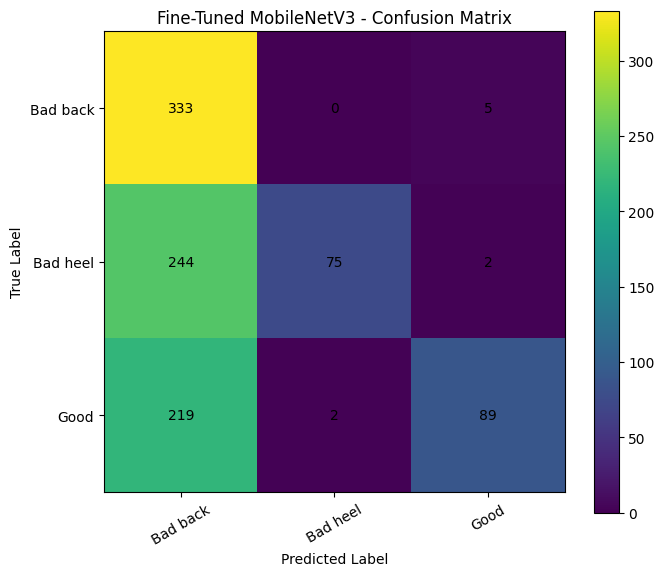

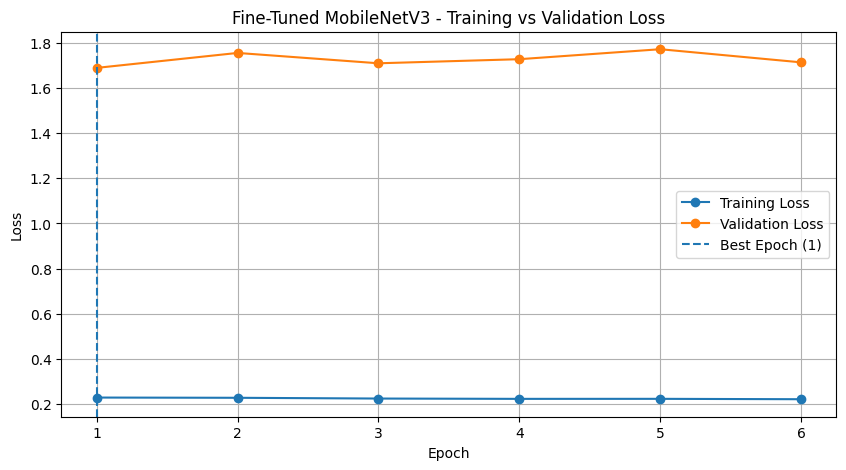

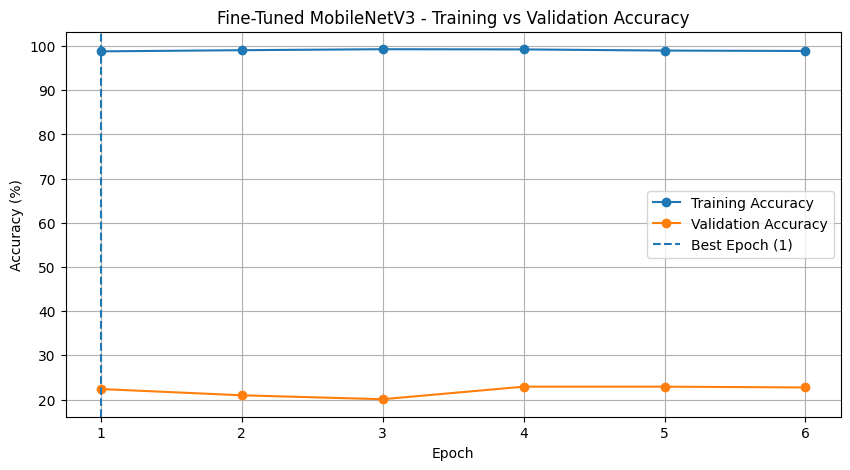


FINAL FINE-TUNING SUMMARY
Best Epoch          : 1
Best Validation Loss: 1.6896
Final Test Accuracy : %51.29


In [18]:
# ============================================================
# MOBILENETV3 FINE-TUNING - COMPLETE FINAL VERSION
# Training + Early Stopping + Best Model
# Test + Classification Report + Confusion Matrix
# Loss & Accuracy Graphs
# ============================================================

import copy
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# ============================================================
# 1. FEATURE BLOCK AYARLARI
# ============================================================

# Önce tüm feature extractor'ı dondur
for param in model_mobilenet.features.parameters():
    param.requires_grad = False

# Son 4 bloğu aç
for param in model_mobilenet.features[-4:].parameters():
    param.requires_grad = True

# Classifier açık
for param in model_mobilenet.classifier.parameters():
    param.requires_grad = True


# ============================================================
# 2. LOSS
# ============================================================

criterion_finetune = nn.CrossEntropyLoss(
    label_smoothing=0.05
)


# ============================================================
# 3. OPTIMIZER
# ============================================================

optimizer_finetune = optim.AdamW(
    [
        {
            "params": model_mobilenet.features[-4:].parameters(),
            "lr": 1e-5
        },
        {
            "params": model_mobilenet.classifier.parameters(),
            "lr": 1e-4
        }
    ],
    weight_decay=1e-4
)


# ============================================================
# 4. SCHEDULER
# ============================================================

scheduler_finetune = optim.lr_scheduler.CosineAnnealingLR(
    optimizer_finetune,
    T_max=20
)


# ============================================================
# 5. SETTINGS
# ============================================================

NUM_FINE_EPOCHS = 20
PATIENCE = 5

best_val_loss_ft = float("inf")
best_epoch_ft = 0
epochs_without_improvement = 0

best_weights_ft = copy.deepcopy(
    model_mobilenet.state_dict()
)

history_finetune = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}


print("=" * 65)
print("🔥 MOBILENETV3 FINE-TUNING BAŞLIYOR")
print("=" * 65)

print("Train      :", len(train_dataset))
print("Validation :", len(val_dataset))
print("Test       :", len(test_dataset))

print("\nOpened Feature Blocks : Last 4")
print("Backbone LR           : 0.00001")
print("Classifier LR         : 0.0001")
print("Maximum Epoch         :", NUM_FINE_EPOCHS)
print("Early Stop Patience   :", PATIENCE)

print()


# ============================================================
# 6. TRAINING LOOP
# ============================================================

for epoch in range(NUM_FINE_EPOCHS):

    # ========================================================
    # TRAIN
    # ========================================================

    model_mobilenet.train()

    train_loss_total = 0.0
    train_correct = 0

    for inputs, labels in train_loader:

        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer_finetune.zero_grad()

        outputs = model_mobilenet(inputs)

        loss = criterion_finetune(
            outputs,
            labels
        )

        _, preds = torch.max(
            outputs,
            1
        )

        loss.backward()

        optimizer_finetune.step()

        train_loss_total += (
            loss.item() * inputs.size(0)
        )

        train_correct += torch.sum(
            preds == labels
        )


    train_loss = (
        train_loss_total
        / len(train_dataset)
    )

    train_acc = (
        train_correct.double()
        / len(train_dataset)
    ).item() * 100


    # ========================================================
    # VALIDATION
    # ========================================================

    model_mobilenet.eval()

    val_loss_total = 0.0
    val_correct = 0

    with torch.no_grad():

        for inputs, labels in val_loader:

            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model_mobilenet(inputs)

            loss = criterion_finetune(
                outputs,
                labels
            )

            _, preds = torch.max(
                outputs,
                1
            )

            val_loss_total += (
                loss.item() * inputs.size(0)
            )

            val_correct += torch.sum(
                preds == labels
            )


    val_loss = (
        val_loss_total
        / len(val_dataset)
    )

    val_acc = (
        val_correct.double()
        / len(val_dataset)
    ).item() * 100


    # ========================================================
    # HISTORY
    # ========================================================

    history_finetune["train_loss"].append(
        train_loss
    )

    history_finetune["train_acc"].append(
        train_acc
    )

    history_finetune["val_loss"].append(
        val_loss
    )

    history_finetune["val_acc"].append(
        val_acc
    )


    # ========================================================
    # PRINT
    # ========================================================

    print(
        f"Epoch {epoch+1:02d}/{NUM_FINE_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} "
        f"- Acc: %{train_acc:.2f} | "
        f"Val Loss: {val_loss:.4f} "
        f"- Acc: %{val_acc:.2f}"
    )


    # ========================================================
    # EARLY STOPPING
    # ========================================================

    if val_loss < best_val_loss_ft:

        best_val_loss_ft = val_loss
        best_epoch_ft = epoch + 1

        best_weights_ft = copy.deepcopy(
            model_mobilenet.state_dict()
        )

        epochs_without_improvement = 0

        print(
            f"   ⭐ New best fine-tuned model! "
            f"Val Loss: {best_val_loss_ft:.4f}"
        )

    else:

        epochs_without_improvement += 1

        print(
            f"   No improvement: "
            f"{epochs_without_improvement}/{PATIENCE}"
        )


    scheduler_finetune.step()


    if epochs_without_improvement >= PATIENCE:

        print("\n" + "=" * 65)

        print(
            f"🛑 EARLY STOPPING at Epoch {epoch+1}"
        )

        print(
            f"⭐ Best Fine-Tune Epoch: "
            f"{best_epoch_ft}"
        )

        print(
            f"⭐ Best Validation Loss: "
            f"{best_val_loss_ft:.4f}"
        )

        print("=" * 65)

        break


# ============================================================
# 7. BEST MODEL'I GERİ YÜKLE
# ============================================================

model_mobilenet.load_state_dict(
    best_weights_ft
)

print("\n✅ Fine-tuning tamamlandı.")

print(
    f"✅ Best Fine-Tune Epoch: {best_epoch_ft}"
)

print(
    f"✅ Best Validation Loss: "
    f"{best_val_loss_ft:.4f}"
)


# ============================================================
# 8. FINAL TEST
# ============================================================

print("\n" + "=" * 65)
print("🚀 FINE-TUNED MOBILENETV3 FINAL TEST")
print("=" * 65)

model_mobilenet.eval()

test_preds_ft = []
test_labels_ft = []

with torch.no_grad():

    for inputs, labels in test_loader:

        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model_mobilenet(inputs)

        _, preds = torch.max(
            outputs,
            1
        )

        test_preds_ft.extend(
            preds.cpu().numpy()
        )

        test_labels_ft.extend(
            labels.cpu().numpy()
        )


# ============================================================
# 9. TEST ACCURACY
# ============================================================

finetuned_test_accuracy = accuracy_score(
    test_labels_ft,
    test_preds_ft
) * 100

print("\n" + "=" * 65)

print(
    f"🎯 FINE-TUNED MOBILENETV3 TEST ACCURACY: "
    f"%{finetuned_test_accuracy:.2f}"
)

print("=" * 65)


# ============================================================
# 10. CLASSIFICATION REPORT
# ============================================================

print("\nCLASSIFICATION REPORT:\n")

print(
    classification_report(
        test_labels_ft,
        test_preds_ft,
        target_names=class_names,
        zero_division=0
    )
)


# ============================================================
# 11. CONFUSION MATRIX
# ============================================================

cm_ft = confusion_matrix(
    test_labels_ft,
    test_preds_ft
)

plt.figure(
    figsize=(7, 6)
)

plt.imshow(
    cm_ft
)

plt.title(
    "Fine-Tuned MobileNetV3 - Confusion Matrix"
)

plt.xlabel(
    "Predicted Label"
)

plt.ylabel(
    "True Label"
)

plt.xticks(
    range(len(class_names)),
    class_names,
    rotation=30
)

plt.yticks(
    range(len(class_names)),
    class_names
)

for i in range(len(class_names)):

    for j in range(len(class_names)):

        plt.text(
            j,
            i,
            cm_ft[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.tight_layout()
plt.show()


# ============================================================
# 12. LOSS GRAPH
# ============================================================

epochs_ft = range(
    1,
    len(history_finetune["train_loss"]) + 1
)

plt.figure(
    figsize=(10, 5)
)

plt.plot(
    epochs_ft,
    history_finetune["train_loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs_ft,
    history_finetune["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.axvline(
    x=best_epoch_ft,
    linestyle="--",
    label=f"Best Epoch ({best_epoch_ft})"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Fine-Tuned MobileNetV3 - Training vs Validation Loss"
)

plt.legend()
plt.grid(True)
plt.show()


# ============================================================
# 13. ACCURACY GRAPH
# ============================================================

plt.figure(
    figsize=(10, 5)
)

plt.plot(
    epochs_ft,
    history_finetune["train_acc"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    epochs_ft,
    history_finetune["val_acc"],
    marker="o",
    label="Validation Accuracy"
)

plt.axvline(
    x=best_epoch_ft,
    linestyle="--",
    label=f"Best Epoch ({best_epoch_ft})"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")

plt.title(
    "Fine-Tuned MobileNetV3 - Training vs Validation Accuracy"
)

plt.legend()
plt.grid(True)
plt.show()


# ============================================================
# 14. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 65)

print("FINAL FINE-TUNING SUMMARY")

print("=" * 65)

print(
    f"Best Epoch          : {best_epoch_ft}"
)

print(
    f"Best Validation Loss: {best_val_loss_ft:.4f}"
)

print(
    f"Final Test Accuracy : %{finetuned_test_accuracy:.2f}"
)

print("=" * 65)

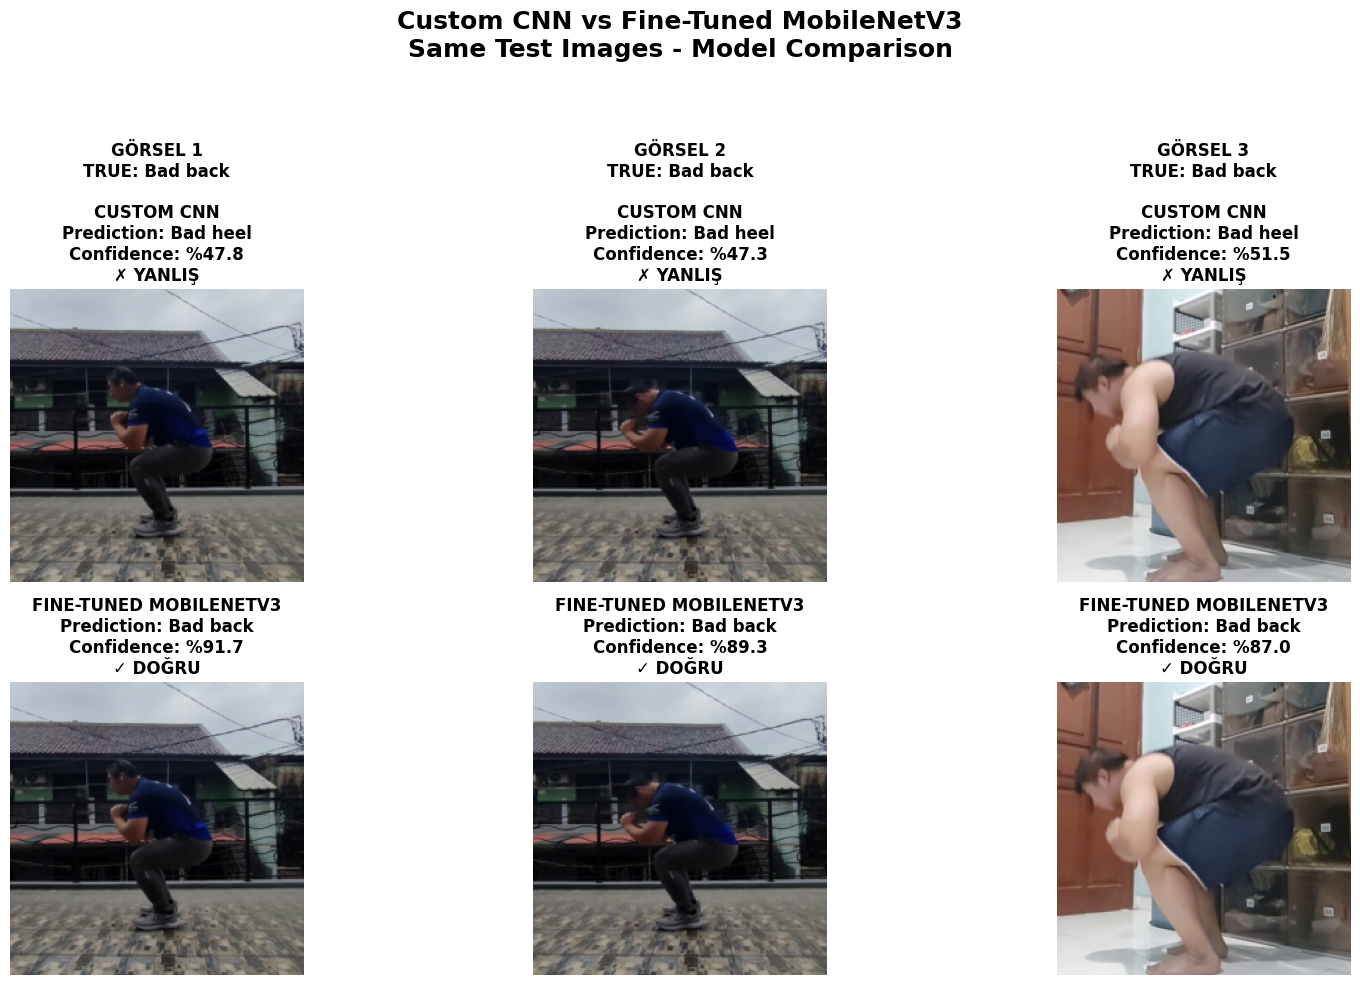

In [25]:
# ============================================================
# 7. HÜCRE
# 3 TEST GÖRSELİ
# ÜST: CUSTOM CNN
# ALT : FINE-TUNED MOBILENETV3
# ============================================================

import random
import torch
import matplotlib.pyplot as plt

NUM_SAMPLES = 3

model_custom.eval()
model_mobilenet.eval()

# 3 farklı rastgele test görüntüsü
random_indices = random.sample(
    range(len(test_dataset)),
    NUM_SAMPLES
)

# ------------------------------------------------------------
# Normalize edilmiş görüntüyü tekrar gösterilebilir hale getir
# ------------------------------------------------------------

def denormalize_image(image):
    image = image.clone().cpu()

    mean = torch.tensor(
        [0.485, 0.456, 0.406]
    ).view(3, 1, 1)

    std = torch.tensor(
        [0.229, 0.224, 0.225]
    ).view(3, 1, 1)

    image = image * std + mean
    image = torch.clamp(image, 0, 1)

    return image.permute(1, 2, 0)


# ------------------------------------------------------------
# 2 SATIR x 3 SÜTUN
# ------------------------------------------------------------

fig, axes = plt.subplots(
    2,
    NUM_SAMPLES,
    figsize=(16, 10)
)

fig.suptitle(
    "Custom CNN vs Fine-Tuned MobileNetV3\n"
    "Same Test Images - Model Comparison",
    fontsize=18,
    fontweight="bold"
)


for col, index in enumerate(random_indices):

    image, true_label = test_dataset[index]

    input_tensor = image.unsqueeze(0).to(device)

    true_class = class_names[true_label]

    # ========================================================
    # CUSTOM CNN
    # ========================================================

    with torch.no_grad():

        cnn_output = model_custom(
            input_tensor
        )

        cnn_probs = torch.softmax(
            cnn_output,
            dim=1
        )

        cnn_confidence, cnn_pred = torch.max(
            cnn_probs,
            dim=1
        )

    cnn_pred_idx = cnn_pred.item()

    cnn_pred_label = class_names[
        cnn_pred_idx
    ]

    cnn_confidence = (
        cnn_confidence.item() * 100
    )

    cnn_correct = (
        cnn_pred_idx == true_label
    )


    # ========================================================
    # FINE-TUNED MOBILENETV3
    # ========================================================

    with torch.no_grad():

        mobile_output = model_mobilenet(
            input_tensor
        )

        mobile_probs = torch.softmax(
            mobile_output,
            dim=1
        )

        mobile_confidence, mobile_pred = torch.max(
            mobile_probs,
            dim=1
        )

    mobile_pred_idx = mobile_pred.item()

    mobile_pred_label = class_names[
        mobile_pred_idx
    ]

    mobile_confidence = (
        mobile_confidence.item() * 100
    )

    mobile_correct = (
        mobile_pred_idx == true_label
    )


    # Görseli hazırla
    display_image = denormalize_image(
        image
    )


    # ========================================================
    # ÜST SATIR -> CUSTOM CNN
    # ========================================================

    axes[0, col].imshow(
        display_image
    )

    axes[0, col].axis("off")

    axes[0, col].set_title(
        f"GÖRSEL {col + 1}\n"
        f"TRUE: {true_class}\n\n"
        f"CUSTOM CNN\n"
        f"Prediction: {cnn_pred_label}\n"
        f"Confidence: %{cnn_confidence:.1f}\n"
        f"{'✓ DOĞRU' if cnn_correct else '✗ YANLIŞ'}",
        fontsize=12,
        fontweight="bold"
    )


    # ========================================================
    # ALT SATIR -> FINE-TUNED MOBILENETV3
    # ========================================================

    axes[1, col].imshow(
        display_image
    )

    axes[1, col].axis("off")

    axes[1, col].set_title(
        f"FINE-TUNED MOBILENETV3\n"
        f"Prediction: {mobile_pred_label}\n"
        f"Confidence: %{mobile_confidence:.1f}\n"
        f"{'✓ DOĞRU' if mobile_correct else '✗ YANLIŞ'}",
        fontsize=12,
        fontweight="bold"
    )


# ------------------------------------------------------------
# Satır etiketleri
# ------------------------------------------------------------

axes[0, 0].set_ylabel(
    "CUSTOM CNN",
    fontsize=15,
    fontweight="bold"
)

axes[1, 0].set_ylabel(
    "FINE-TUNED\nMOBILENETV3",
    fontsize=15,
    fontweight="bold"
)


plt.tight_layout(
    rect=[0, 0, 1, 0.93]
)

plt.show()